<a href="https://colab.research.google.com/github/LaurenMitchell-tech/uvvisml/blob/main/CIE_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Use to allow gpu use. Skip if using cpu.
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 115.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 108.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 55.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 85.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.

In [2]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    try:
        import chemprop
    except ImportError:
        !git clone https://github.com/chemprop/chemprop.git
        %cd chemprop
        !pip install .
        %cd examples

from lightning import pytorch as pl
import torch
import numpy as np
import pandas as pd
from pathlib import Path

import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from chemprop import data, featurizers, models, nn
from chemprop.nn import metrics
from chemprop.models import multi

Cloning into 'chemprop'...
remote: Enumerating objects: 25475, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 25475 (delta 131), reused 46 (delta 46), pack-reused 25255 (from 4)
Receiving objects: 100% (25475/25475), 876.92 MiB | 16.04 MiB/s, done.
Resolving deltas: 100% (18263/18263), done.
Updating files: 100% (337/337), done.
/content/chemprop
Processing /content/chemprop
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [23]:
from google.colab import files
uploaded = files.upload()

Saving Deep4Chem_CIE_Coordinates_FWHM(cm-1).csv to Deep4Chem_CIE_Coordinates_FWHM(cm-1).csv
Saving Deep4Chem_CIE_Coordinates_FWHM(nm).csv to Deep4Chem_CIE_Coordinates_FWHM(nm).csv


In [57]:
chemprop_dir = Path.cwd().parent
input_path = chemprop_dir / "examples" / "Deep4Chem_CIE_Coordinates_Complete.csv"
smiles_columns = ['Chromophore', 'Solvent']
target_columns = ["X","Y"]

df_input = pd.read_csv(input_path, usecols=['Chromophore','Solvent', 'X', 'Y'])
smiss = df_input.loc[:, smiles_columns].values
ys = df_input.loc[:, target_columns].values

datapoints = [[data.MoleculeDatapoint.from_smi(smis[0], y) for smis, y in zip(smiss, ys)]]
datapoints += [[data.MoleculeDatapoint.from_smi(smis[i]) for smis in smiss] for i in range(1, len(smiles_columns))]

In [58]:
df_input

,Chromophore,Solvent,X,Y
0,N#Cc1cc2ccc([O-])cc2oc1=O,O,0.149727,0.029648
1,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CC#N,0.357314,0.610118
2,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CS(C)=O,0.355870,0.629721
3,c1ccc2ccccc2c1,C1CCCCC1,0.174327,0.005065
4,C[Si](C)(C)c1cccc2ccccc12,C1CCCCC1,0.174370,0.005076
...,...,...,...,...
7738,CN(C)c1ccc(C2=Cc3cccc[n+]3[B-](F)(F)O2)cc1,ClC(Cl)Cl,0.131381,0.311698
7739,CN1CCc2cc(C3=Cc4cccc[n+]4[B-](F)(F)O3)ccc21,ClC(Cl)Cl,0.200724,0.546418
7740,F[B-]1(F)OC(c2ccc(N3CCCC3)cc2)=Cc2cccc[n+]21,ClC(Cl)Cl,0.155260,0.369463
7741,CN1CCCc2cc(C3=Cc4cccc[n+]4[B-](F)(F)O3)ccc21,ClC(Cl)Cl,0.189495,0.471387


In [59]:
#multicomponent code
component_to_split_by = 0 # index of the component to use for structure based splits
mols = [d.mol for d in datapoints[component_to_split_by]]

train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))
train_data, val_data, test_data = data.split_data_by_indices(
    datapoints, train_indices, val_indices, test_indices
)

In [60]:
#Display test set
test_indices = [idx for sublist in test_indices for idx in sublist]
df_test = df_input.iloc[test_indices].reset_index(drop=True)
df_test

,Chromophore,Solvent,X,Y
0,CCC1(CC)c2cc(/C=C/c3cc(C#N)c(/C=C/c4ccc5c(c4)C...,Cc1ccccc1,0.331246,0.573426
1,CCCCN1C(=O)C(=CC=C2N(CCCC)c3ccccc3N2CCCC)C(=O)...,ClC(Cl)Cl,0.076767,0.275994
2,c1ccc2cc(-n3cnc4ccccc43)ccc2c1,CCOC(C)=O,0.171211,0.005811
3,CCOC(=O)c1ccc(C2CC(c3cccc4ccccc34)=NN2c2ccc(OC...,ClCCl,0.159675,0.407328
4,CN(C)c1ccc2c(c1)COc1c-2oc2ccccc2c1=O,CC#N,0.116661,0.287615
...,...,...,...,...
770,O=Cc1ccc2c(c1)c1ccccc1n2-c1ccc(-c2ccc(-n3c4ccc...,ClCCl,0.154996,0.029540
771,COc1cc2[nH]c3c(c2cc1OCC(=O)O)CCCC3=O,O,0.140375,0.211279
772,CCCCC1=Cc2c3ccc4cccc5ccc(c6cc(-c7ccc(N(c8ccccc...,CC#N,0.421296,0.514883
773,CC1(C)Nc2cc(Cl)ccc2-c2[nH]c3ccccc3c(=O)c21,ClCCl,0.131291,0.163155


In [61]:
#multicomponent code
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

train_dset = [data.MoleculeDataset(train_data[0][i], featurizer) for i in range(len(smiles_columns))]
val_dset = [data.MoleculeDataset(val_data[0][i], featurizer) for i in range(len(smiles_columns))]
test_dset = [data.MoleculeDataset(test_data[0][i], featurizer) for i in range(len(smiles_columns))]

train_mcdset = data.MulticomponentDataset(train_dset)
scaler = train_mcdset.normalize_targets()
val_mcdset = data.MulticomponentDataset(val_dset)
val_mcdset.normalize_targets(scaler)
test_mcdset = data.MulticomponentDataset(test_dset)

BATCH_SIZE = 16
train_loader = data.build_dataloader(train_mcdset, batch_size=BATCH_SIZE)
val_loader = data.build_dataloader(val_mcdset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.build_dataloader(test_mcdset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
#multicomponent code

torch.manual_seed(0) #use same random seed every time
np.random.seed(0)

mcmp = nn.MulticomponentMessagePassing(
    blocks=[nn.BondMessagePassing() for _ in range(len(smiles_columns))],
    n_components=len(smiles_columns),
)

agg = nn.MeanAggregation()

In [12]:
#multicomponent code, could add dropout in the FFN (e.g., dropout=0.2–0.5)
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

ffn = nn.RegressionFFN(
    n_tasks = len(target_columns),
    input_dim=mcmp.output_dim,
    output_transform=output_transform,
)

metric_list = [metrics.RMSE(), metrics.MAE()] # Only the first metric is used for training and early stopping

In [13]:
#multicomponent code
mcmpnn = multi.MulticomponentMPNN(
    mcmp,
    agg,
    ffn,
    metrics=metric_list,
)

mcmpnn

MulticomponentMPNN(
  (message_passing): MulticomponentMessagePassing(
    (blocks): ModuleList(
      (0-1): 2 x BondMessagePassing(
        (W_i): Linear(in_features=86, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=372, out_features=300, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (tau): ReLU()
        (V_d_transform): Identity()
        (graph_transform): Identity()
      )
    )
  )
  (agg): MeanAggregation()
  (bn): Identity()
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=600, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=2, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0, 1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleL

In [62]:
#code for training a model which will be saved
checkpoint = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints/",
    monitor="val_loss",
    save_top_k=1,
    mode="min",
    filename="CIE_model_0"
)

early_stop = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=50,
    mode="min"
)

from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(mcmpnn.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

Torch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1


In [63]:
#multicomponent code
trainer = pl.Trainer(accelerator="auto", logger=True, callbacks=[checkpoint, early_stop], max_epochs=100, deterministic=True) #enable_checkpointing=False,

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [16]:
#multicomponent code
trainer.fit(mcmpnn, train_loader, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ MulticomponentMessagePassing │  455 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation              │      0 │ train │     0 │
│ 2 │ bn              │ Identity                     │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN                │  180 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity                     │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList                   │      0 │ train │     0 │
└───┴─────────────────┴──────────────────────────────┴────────┴───────┴───────┘

Trainable params: 636 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 636 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


In [53]:
#Code for loading different model than the one just trained
path = chemprop_dir / "examples" / "CIE_model_nm.ckpt"
mcmpnn = models.multi.MulticomponentMPNN.load_from_checkpoint(path, map_location="cpu", weights_only=False)

In [22]:
#Show where model is saved
best_model_path = checkpoint.best_model_path
print(f"Best model saved at: {best_model_path}")

#from google.colab import files
#files.download(best_model_path)

Best model saved at: /content/chemprop/examples/checkpoints/CIE_model_1.ckpt


In [64]:
#Predict and show results compared to known data
preds = trainer.predict(mcmpnn, test_loader) #Works with mcmpnn or chemprop_model
preds_tensor = torch.cat(preds, dim=0)

preds_array = preds_tensor.detach().cpu().numpy()

columns = ['Pred_X', 'Pred_Y']
df_test[columns] = preds_array

df_test

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


,Chromophore,Solvent,X,Y,Pred_X,Pred_Y
0,CCC1(CC)c2cc(/C=C/c3cc(C#N)c(/C=C/c4ccc5c(c4)C...,Cc1ccccc1,0.331246,0.573426,0.254164,0.395818
1,CCCCN1C(=O)C(=CC=C2N(CCCC)c3ccccc3N2CCCC)C(=O)...,ClC(Cl)Cl,0.076767,0.275994,0.424232,0.498696
2,c1ccc2cc(-n3cnc4ccccc43)ccc2c1,CCOC(C)=O,0.171211,0.005811,0.177124,0.028794
3,CCOC(=O)c1ccc(C2CC(c3cccc4ccccc34)=NN2c2ccc(OC...,ClCCl,0.159675,0.407328,0.151866,0.172631
4,CN(C)c1ccc2c(c1)COc1c-2oc2ccccc2c1=O,CC#N,0.116661,0.287615,0.200981,0.293559
...,...,...,...,...,...,...
770,O=Cc1ccc2c(c1)c1ccccc1n2-c1ccc(-c2ccc(-n3c4ccc...,ClCCl,0.154996,0.029540,0.143349,0.087040
771,COc1cc2[nH]c3c(c2cc1OCC(=O)O)CCCC3=O,O,0.140375,0.211279,0.195880,0.228325
772,CCCCC1=Cc2c3ccc4cccc5ccc(c6cc(-c7ccc(N(c8ccccc...,CC#N,0.421296,0.514883,0.342591,0.520423
773,CC1(C)Nc2cc(Cl)ccc2-c2[nH]c3ccccc3c(=O)c21,ClCCl,0.131291,0.163155,0.126955,0.331506


In [19]:
def plot_and_save(true_values=str, preds=str, model=str, value_type=str, save_path=str):

  '''
  true_values: name of column containing experimental x or y values
  preds: name of column containing predicted x or y values
  model: name of model used to make prediction
  save_path: path where figure will be saved

  plots a parity plot and saves the figure to the specified path
  '''

  true_ys = df_test[true_values].tolist()
  preds_y = df_test[preds].tolist()

  fig = plt.figure(figsize=(8,5))
  plt.scatter(true_ys, preds_y, color='red', marker='o', label='Parity Plot')
  ax = plt.gca()
  lims = ax.get_xlim()
  ax.plot(lims, lims, color='black')
  plt.legend()
  plt.xlabel('Actual')
  plt.ylabel('Predicted')
  title = 'Parity Plot of ' + model + ' ' + value_type + ' Values'
  plt.title(title)
  plt.grid(True)

  with open(save_path, "wb") as f:
      pickle.dump(fig, f)

  plt.show()

  print('Plot saved as: ' + save_path)

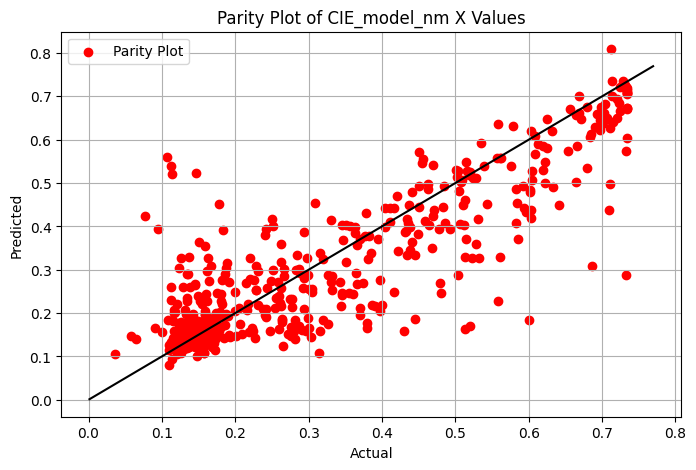

Plot saved as: X_Parity_CIE_model_nm_mixed_data.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
plot_and_save('X', 'Pred_X', 'CIE_model_nm', 'X', 'X_Parity_CIE_model_nm_mixed_data.pkl')

from google.colab import files
files.download('X_Parity_CIE_model_nm_mixed_data.pkl')

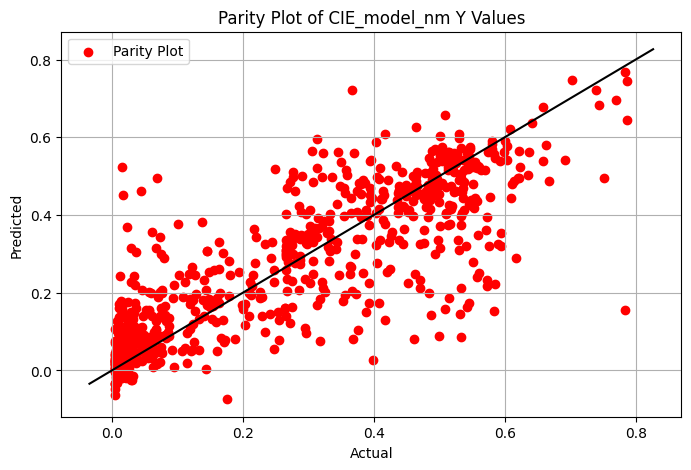

Plot saved as: Y_Parity_CIE_model_nm_mixed_data.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
plot_and_save('Y', 'Pred_Y', 'CIE_model_nm', 'Y', 'Y_Parity_CIE_model_nm_mixed_data.pkl')

from google.colab import files
files.download('Y_Parity_CIE_model_nm_mixed_data.pkl')